# **F**atigue & **R**hythm RAG

Raw RAG resume la calidad base de cada jugador. Esta segunda capa pregunta algo distinto: **¿en qué estado llega ese jugador al partido?**

In [ ]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.linear_model import Ridge, RidgeCV
from patsy import dmatrix, build_design_matrices
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)
SEED = 42
BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"

plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "font.size": 12, "axes.titleweight": "bold",
})

def finish_chart(fig, subtitle, subtitle_y=0.90):
    fig.text(0.06, subtitle_y, subtitle, fontsize=10.5, color=MUTED, ha="left")

def clean_axes(ax, grid_axis="y", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

raw = pd.read_csv(DATA_DIR / "raw_rag_la_liga.csv", encoding="utf-8-sig")
fr = pd.read_csv(DATA_DIR / "player_fatigue_rhythm.csv", encoding="utf-8-sig")
match_history = pd.read_csv(DATA_DIR / "featured_player_match_history.csv", encoding="utf-8-sig")
raw["date"] = pd.to_datetime(raw["date"])
fr["match_date"] = pd.to_datetime(fr["match_date"])
match_history["match_date"] = pd.to_datetime(match_history["match_date"])
for column in ["teamA_players", "teamB_players"]:
    raw[column] = raw[column].apply(json.loads)

required_fr_columns = {
    "match_id", "match_date", "league_id", "league_name", "home_team", "away_team",
    "player_id", "fatigue", "rhythm", "r_adjustment", "f_adjustment",
}
assert required_fr_columns.issubset(fr.columns)
assert len(fr) == 64_567
assert not fr.duplicated(["match_id", "player_id"]).any()
assert fr[list(required_fr_columns)].notna().all().all()
assert fr[["fatigue", "rhythm"]].apply(lambda s: s.between(0, 1).all()).all()
assert np.isfinite(fr[["fatigue", "rhythm", "r_adjustment", "f_adjustment"]]).all().all()
required_history_columns = {"match_date", "player_id", "minutes_played"}
assert set(match_history.columns) == required_history_columns
assert len(match_history) == 1_726
assert match_history["player_id"].nunique() == 22
assert (match_history["player_id"] == "Lamine Yamal_19_B").sum() == 98
assert (match_history["player_id"] == "Kylian Mbappé_9_RM").sum() == 48
assert not match_history.duplicated(["player_id", "match_date"]).any()
assert match_history.notna().all().all()
assert (match_history["minutes_played"] > 0).all()
assert (match_history["match_date"] < pd.Timestamp("2025-05-11")).all()
import pickle
import numpy as np
import pandas as pd
from patsy import dmatrix


def export_model(path, model, design_info, feature):
    factor = next(iter(design_info.factor_infos.values()))
    spline = next(iter(factor.state['transforms'].values()))
    degree = spline._degree
    knots = spline._all_knots[degree + 1:-(degree + 1)].tolist()
    formula = (f"bs({feature}, knots={knots!r}, degree={degree}, "
               "include_intercept=False, lower_bound=0.0, upper_bound=1.0)")
    artifact = dict(version=1, df=3, degree=degree, feature=feature,
                    knots=knots, formula=formula, model=model)
    with open(path, 'wb') as file:
        pickle.dump(artifact, file)
    return artifact


def load_model(path):
    with open(path, 'rb') as file:
        artifact = pickle.load(file)
    assert artifact['df'] == 3 and artifact['degree'] == 2
    return artifact


def predict_model(artifact, values):
    values = np.clip(np.asarray(values, dtype=float).reshape(-1), 0, 1)
    matrix = np.asarray(dmatrix(artifact['formula'], {artifact['feature']: values}))
    assert matrix.shape[1] == artifact['model'].n_features_in_
    matrix = pd.DataFrame(matrix, columns=artifact['model'].feature_names_in_)
    return artifact['model'].predict(matrix)




## Proceso del FR-RAG

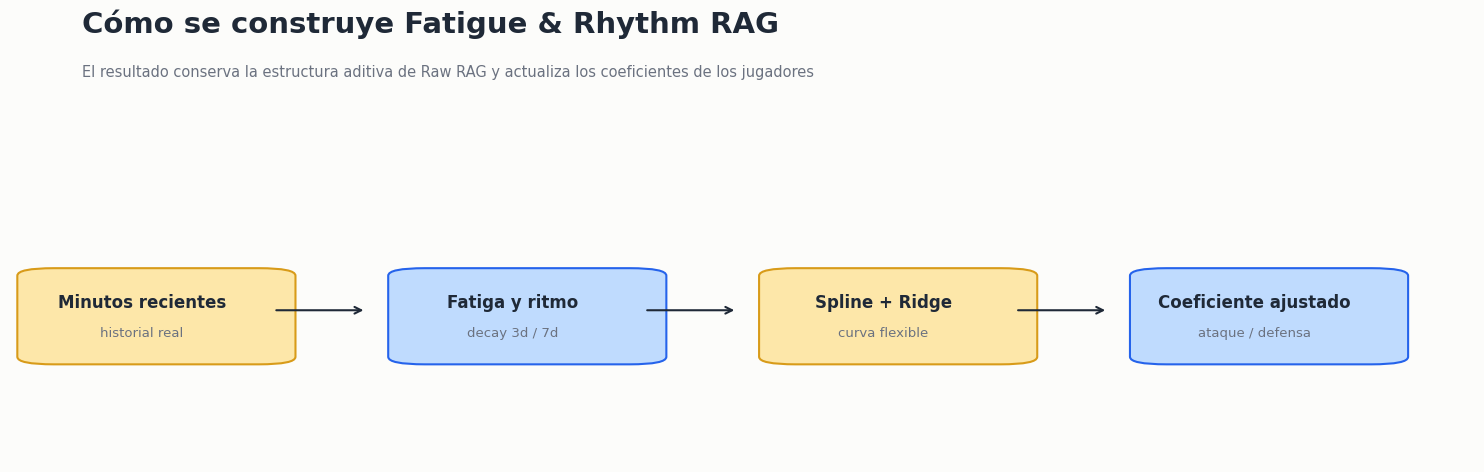

In [2]:
fig, ax = plt.subplots(figsize=(15, 4.8))
steps = [
    ("Minutos recientes", "historial real"),
    ("Fatiga y ritmo", "decay 3d / 7d"),
    ("Spline + Ridge", "curva flexible"),
    ("Coeficiente ajustado", "ataque / defensa"),
]
x_positions = np.linspace(0.09, 0.85, len(steps))
for index, ((title, subtitle), x) in enumerate(zip(steps, x_positions)):
    face = BLUE_LIGHT if index in (1, 3) else GOLD_LIGHT
    edge = BLUE if index in (1, 3) else GOLD
    box = FancyBboxPatch((x - 0.07, 0.34), 0.16, 0.29,
                         boxstyle="round,pad=0.015,rounding_size=0.025",
                         transform=ax.transAxes, facecolor=face, edgecolor=edge, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, 0.53, title, transform=ax.transAxes, ha="center", va="center",
            fontweight="bold", fontsize=12)
    ax.text(x, 0.43, subtitle, transform=ax.transAxes, ha="center", va="center",
            color=MUTED, fontsize=9.5)
    if index < len(steps) - 1:
        ax.annotate("", xy=(x_positions[index + 1] - 0.10, 0.505), xytext=(x + 0.09, 0.505),
                    xycoords=ax.transAxes, arrowprops=dict(arrowstyle="->", color=INK, linewidth=1.5))
ax.axis("off")
fig.suptitle("Cómo se construye Fatigue & Rhythm RAG", x=0.06, y=0.98, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "El resultado conserva la estructura aditiva de Raw RAG y actualiza los coeficientes de los jugadores", subtitle_y=0.84)
plt.tight_layout(rect=(0, 0, 1, 0.80))
plt.show()

## Dos memorias para dos preguntas

La fatiga usa un decay de **3 días** porque busca representar la carga inmediata. El ritmo usa un decay de **7 días** porque la continuidad tarda más en desaparecer.

Cuando han pasado exactamente $\tau$ días, los minutos conservan aproximadamente el **37% de su peso original**.

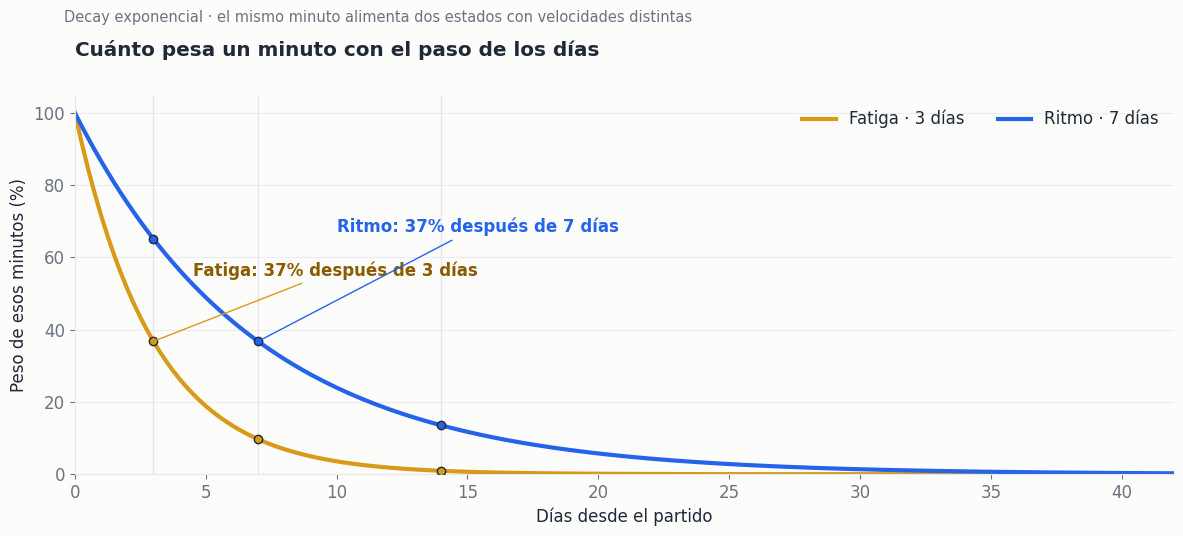

In [3]:
days = np.arange(0, 43, 0.25)
fatigue_weight = np.exp(-days / 3)
rhythm_weight = np.exp(-days / 7)
fig, ax = plt.subplots(figsize=(12, 5.8))
ax.plot(days, fatigue_weight * 100, color=GOLD, linewidth=3, label="Fatiga · 3 días")
ax.plot(days, rhythm_weight * 100, color=BLUE, linewidth=3, label="Ritmo · 7 días")
for day in [3, 7, 14]:
    ax.axvline(day, color=GRID, linewidth=1)
    ax.scatter(day, np.exp(-day / 3) * 100, color=GOLD, edgecolor=INK, zorder=3)
    ax.scatter(day, np.exp(-day / 7) * 100, color=BLUE, edgecolor=INK, zorder=3)
ax.annotate("Fatiga: 37% después de 3 días", (3, np.exp(-1) * 100), xytext=(4.5, 55),
            textcoords="data", color="#8A5C00", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=GOLD))
ax.annotate("Ritmo: 37% después de 7 días", (7, np.exp(-1) * 100), xytext=(10, 67),
            textcoords="data", color=BLUE, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=BLUE))
ax.set(xlabel="Días desde el partido", ylabel="Peso de esos minutos (%)", xlim=(0, 42), ylim=(0, 105))
ax.set_title("Cuánto pesa un minuto con el paso de los días", loc="left", pad=28)
ax.legend(frameon=False, ncol=2, loc="upper right")
clean_axes(ax)
finish_chart(fig, "Decay exponencial · el mismo minuto alimenta dos estados con velocidades distintas")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

## Las curvas que aprende el modelo

Una relación lineal obligaría a que cada incremento de fatiga o ritmo tuviera siempre el mismo efecto. Los **splines cuadráticos** permiten que la forma cambie a lo largo del rango. `Ridge` suaviza esa flexibilidad para evitar curvas innecesariamente extremas.

El ritmo se conecta con el ajuste ofensivo (`r_adjustment`) y la fatiga con el defensivo (`f_adjustment`). Los valores se muestran como xG por 90 para que sean comparables con los coeficientes de Raw RAG.

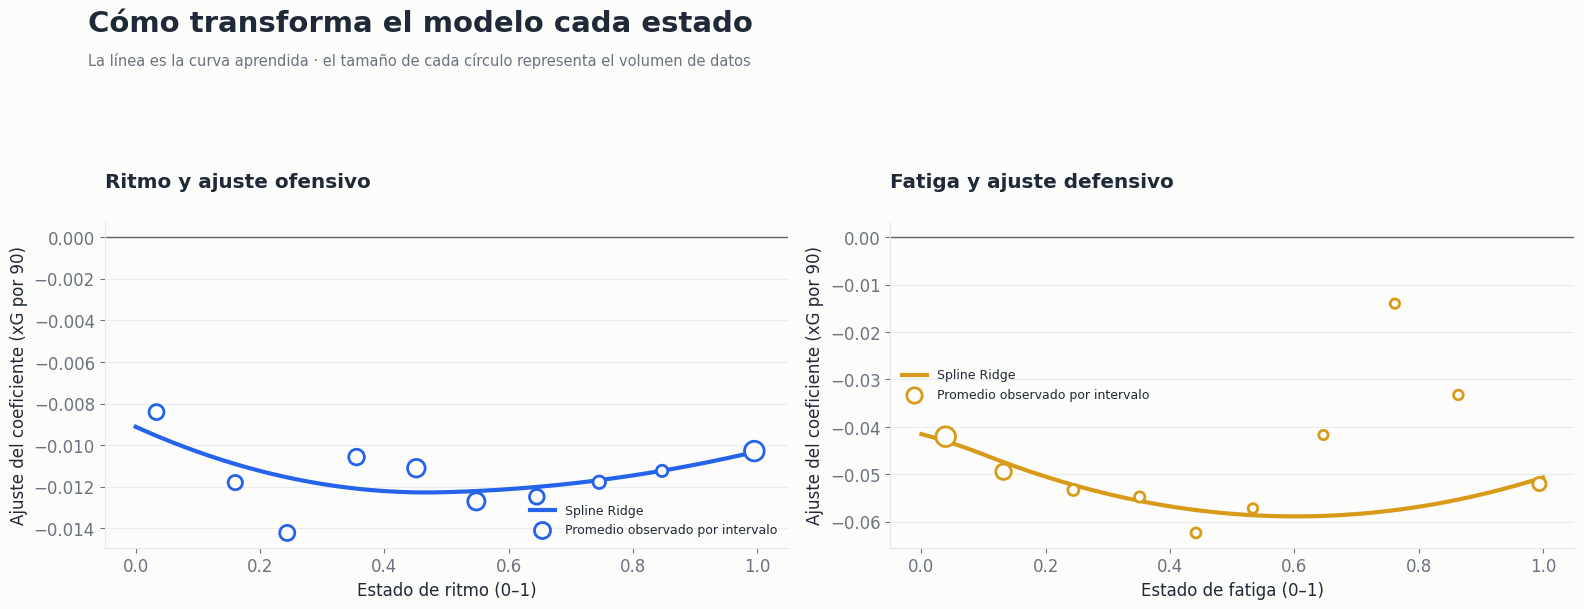

In [4]:
def fit_adjustment_model(frame, feature, target):
    design = dmatrix(
        f"bs({feature}, df=3, degree=2, include_intercept=False, lower_bound=0.0, upper_bound=1.0)",
        data=frame, return_type="dataframe",
    )
    model = Ridge(alpha=1e-5)
    model.fit(design, frame[target])
    return model, design.design_info

def predict_adjustment(model, design_info, feature, values):
    values = np.clip(np.asarray(values, dtype=float), 0, 1)
    matrix = build_design_matrices([design_info], {feature: values})[0]
    return model.predict(matrix)

rhythm_model, rhythm_design = fit_adjustment_model(fr, "rhythm", "r_adjustment")
fatigue_model, fatigue_design = fit_adjustment_model(fr, "fatigue", "f_adjustment")

curve_specs = [
    ("rhythm", "r_adjustment", rhythm_model, rhythm_design,
     "Ritmo y ajuste ofensivo", BLUE, "Ritmo"),
    ("fatigue", "f_adjustment", fatigue_model, fatigue_design,
     "Fatiga y ajuste defensivo", GOLD, "Fatiga"),
]
grid = np.linspace(0, 1, 301)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.2))
for ax, (feature, target, model, design_info, title, color, xlabel) in zip(axes, curve_specs):
    bins = pd.cut(fr[feature], np.linspace(0, 1, 11), include_lowest=True)
    observed = fr.groupby(bins, observed=True).agg(
        feature_mean=(feature, "mean"), adjustment=(target, "mean"), count=(target, "size")
    ).reset_index(drop=True)
    predicted = predict_adjustment(model, design_info, feature, grid) * 90
    sizes = 45 + 155 * observed["count"] / observed["count"].max()
    ax.axhline(0, color=INK, linewidth=1, alpha=0.7)
    ax.plot(grid, predicted, color=color, linewidth=3, label="Spline Ridge")
    ax.scatter(observed["feature_mean"], observed["adjustment"] * 90, s=sizes,
               facecolor=PAPER, edgecolor=color, linewidth=2, zorder=3,
               label="Promedio observado por intervalo")
    ax.set_title(title, loc="left", pad=25)
    ax.set_xlabel(f"Estado de {xlabel.lower()} (0–1)")
    ax.set_ylabel("Ajuste del coeficiente (xG por 90)")
    ax.legend(frameon=False, fontsize=9, loc="best")
    clean_axes(ax)
fig.suptitle("Cómo transforma el modelo cada estado", x=0.06, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "La línea es la curva aprendida · el tamaño de cada círculo representa el volumen de datos", subtitle_y=0.89)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()
for feature, model, design_info in [("rhythm", rhythm_model, rhythm_design), ("fatigue", fatigue_model, fatigue_design)]:
    artifact = export_model(DATA_DIR / f"{feature}_model.pkl", model, design_info, feature)
    restored = load_model(DATA_DIR / f"{feature}_model.pkl")
    probe = np.r_[np.linspace(0, 1, 301), fr[feature].to_numpy()]
    np.testing.assert_allclose(predict_model(restored, probe), predict_adjustment(model, design_info, feature, probe), rtol=1e-12, atol=1e-12)


## Datos reales

Barcelona y Real Madrid llegaron al Clásico del **11 de mayo de 2025** con cargas diferentes. 

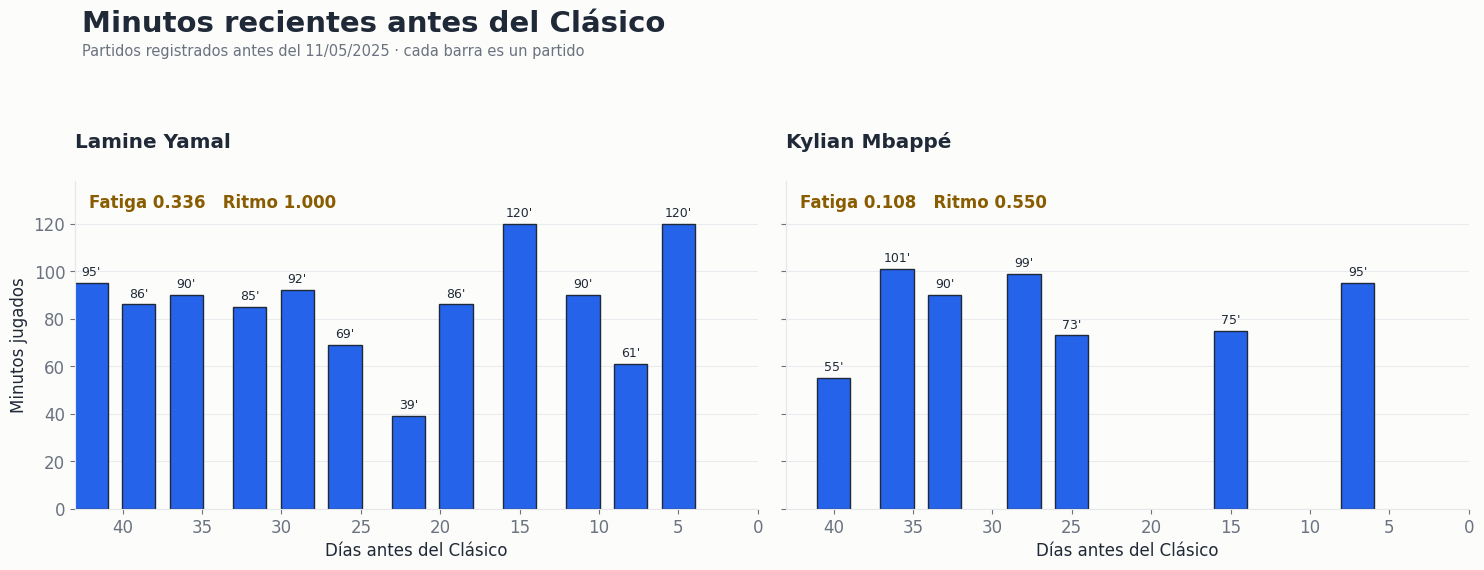

In [5]:
CLASICO_ID = 28055
CLASICO_DATE = pd.Timestamp("2025-05-11")
clasico = raw[raw["match_id"] == CLASICO_ID].sort_values("segment_id")
assert len(clasico) == 19
assert clasico["minutes_played"].sum() == 98

first_segment = clasico.iloc[0]
barcelona_xi = first_segment["teamA_players"]
madrid_xi = first_segment["teamB_players"]

player_matches = match_history[
    match_history["match_date"] < CLASICO_DATE
].rename(columns={"match_date": "date", "minutes_played": "minutes"}).copy()

def fatigue_rhythm_before(player_id, reference_date=CLASICO_DATE):
    matches = player_matches[player_matches["player_id"] == player_id].copy()
    days_ago = (reference_date.normalize() - matches["date"].dt.normalize()).dt.days
    fatigue = min(1.0, (matches["minutes"] * np.exp(-days_ago / 3.0)).sum() / 90.0)
    rhythm = min(1.0, (matches["minutes"] * np.exp(-days_ago / 7.0)).sum() / 90.0)
    return fatigue, rhythm

featured_players = {
    "Lamine Yamal": "Lamine Yamal_19_B",
    "Kylian Mbappé": "Kylian Mbappé_9_RM",
}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), sharey=True)
for ax, (label, player_id) in zip(axes, featured_players.items()):
    recent = player_matches[
        (player_matches["player_id"] == player_id)
        & (player_matches["date"] >= CLASICO_DATE - pd.Timedelta(days=42))
    ].copy()
    recent["days_ago"] = (CLASICO_DATE.normalize() - recent["date"].dt.normalize()).dt.days
    fatigue, rhythm = fatigue_rhythm_before(player_id)
    bars = ax.bar(recent["days_ago"], recent["minutes"], width=2.1, color=BLUE, edgecolor=INK)
    ax.bar_label(bars, labels=[f"{int(v)}'" for v in recent["minutes"]], padding=3, fontsize=9)
    ax.set_title(label, loc="left", pad=24)
    ax.text(0.02, 0.96, f"Fatiga {fatigue:.3f}   Ritmo {rhythm:.3f}", transform=ax.transAxes,
            va="top", color="#8A5C00", fontweight="bold")
    ax.set_xlabel("Días antes del Clásico")
    ax.set_xlim(43, 0)
    ax.set_ylim(0, 138)
    clean_axes(ax)
axes[0].set_ylabel("Minutos jugados")
fig.suptitle("Minutos recientes antes del Clásico", x=0.06, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "Partidos registrados antes del 11/05/2025 · cada barra es un partido")
plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

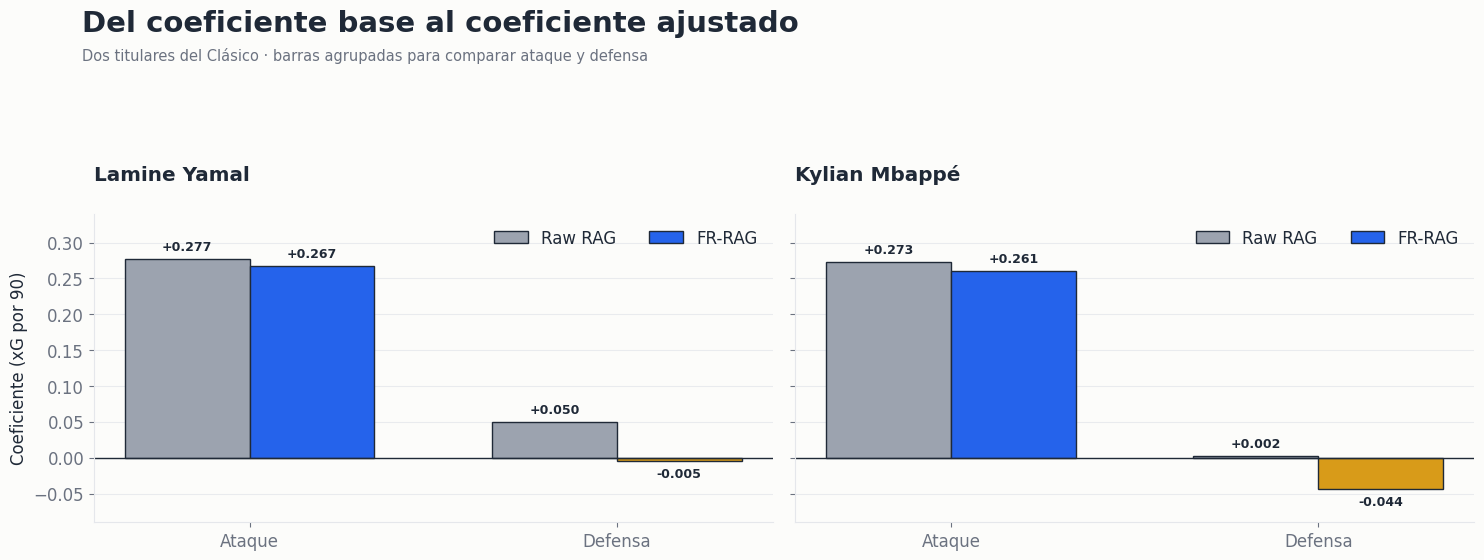

In [6]:
def fit_raw_rag(frame, reference_date=None):
    model_data = frame.copy()
    reference_date = pd.Timestamp(reference_date or model_data["date"].max())
    model_data["days_ago"] = (reference_date - model_data["date"]).dt.days
    model_data["time_weight"] = np.exp(-np.log(2) * model_data["days_ago"] / 180)
    model_data["time_weight"] *= len(model_data) / model_data["time_weight"].sum()
    players = sorted(set().union(*model_data["teamA_players"], *model_data["teamB_players"]))
    player_index = {player: index for index, player in enumerate(players)}
    n_players = len(players)
    rows, cols, values, target, weights = [], [], [], [], []
    for row_number, (_, segment) in enumerate(model_data.iterrows()):
        minutes = int(segment["minutes_played"])
        for perspective, (attackers, defenders, xg) in enumerate([
            (segment["teamA_players"], segment["teamB_players"], segment["teamA_xg"]),
            (segment["teamB_players"], segment["teamA_players"], segment["teamB_xg"]),
        ]):
            design_row = row_number * 2 + perspective
            for player in attackers:
                rows.append(design_row); cols.append(player_index[player]); values.append(1)
            for player in defenders:
                rows.append(design_row); cols.append(n_players + player_index[player]); values.append(-1)
            target.append(float(xg) / minutes)
            weights.append(np.sqrt(minutes * float(segment["time_weight"])))
    matrix = sparse.csr_matrix((values, (rows, cols)), shape=(len(model_data) * 2, n_players * 2))
    target, weights = np.asarray(target), np.asarray(weights)
    target_mean = np.average(target, weights=weights)
    centered = target - target_mean
    selector = RidgeCV(alphas=np.logspace(-3, 3, 13), fit_intercept=True, cv=5)
    selector.fit(matrix, centered, sample_weight=weights)
    model = Ridge(alpha=selector.alpha_, fit_intercept=True)
    model.fit(matrix, centered, sample_weight=weights)
    ratings = pd.DataFrame({
        "player": players,
        "off_90": model.coef_[:n_players] * 90,
        "def_90": model.coef_[n_players:] * 90,
    }).set_index("player")
    return float((model.intercept_ + target_mean) * 90), ratings, float(selector.alpha_)

baseline_90, raw_ratings, raw_alpha = fit_raw_rag(raw, raw["date"].max())
lineup_ids = barcelona_xi + madrid_xi
lineup_state = pd.DataFrame([
    {"player": player, "fatigue": fatigue_rhythm_before(player)[0],
     "rhythm": fatigue_rhythm_before(player)[1]}
    for player in lineup_ids
]).set_index("player")
lineup_state["rhythm_adjustment_90"] = predict_adjustment(
    rhythm_model, rhythm_design, "rhythm", lineup_state["rhythm"]
) * 90
lineup_state["fatigue_adjustment_90"] = predict_adjustment(
    fatigue_model, fatigue_design, "fatigue", lineup_state["fatigue"]
) * 90
lineup_state = lineup_state.join(raw_ratings)
lineup_state["fr_off_90"] = lineup_state["off_90"] + lineup_state["rhythm_adjustment_90"]
lineup_state["fr_def_90"] = lineup_state["def_90"] + lineup_state["fatigue_adjustment_90"]

examples = lineup_state.loc[["Lamine Yamal_19_B", "Kylian Mbappé_9_RM"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5.7), sharey=True)
example_labels = ["Lamine Yamal", "Kylian Mbappé"]
for ax, (player_id, label) in zip(axes, zip(examples.index, example_labels)):
    row = examples.loc[player_id]
    x = np.arange(2)
    raw_values = [row["off_90"], row["def_90"]]
    adjusted_values = [row["fr_off_90"], row["fr_def_90"]]
    width = 0.34
    raw_bars = ax.bar(x - width / 2, raw_values, width, color=GREY, edgecolor=INK, label="Raw RAG")
    fr_bars = ax.bar(x + width / 2, adjusted_values, width,
                     color=[BLUE, GOLD], edgecolor=INK, label="FR-RAG")
    for bars in (raw_bars, fr_bars):
        for bar in bars:
            value = bar.get_height()
            offset = 0.008 if value >= 0 else -0.008
            ax.text(bar.get_x() + bar.get_width() / 2, value + offset, f"{value:+.3f}",
                    ha="center", va="bottom" if value >= 0 else "top", fontsize=9, fontweight="bold")
    ax.axhline(0, color=INK, linewidth=1)
    ax.set_xticks(x, ["Ataque", "Defensa"])
    ax.set_title(label, loc="left", pad=24)
    ax.legend(frameon=False, ncol=2, loc="upper right")
    clean_axes(ax)
axes[0].set_ylabel("Coeficiente (xG por 90)")
axes[0].set_ylim(-0.09, 0.34)
fig.suptitle("Del coeficiente base al coeficiente ajustado", x=0.06, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "Dos titulares del Clásico · barras agrupadas para comparar ataque y defensa", subtitle_y=0.89)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

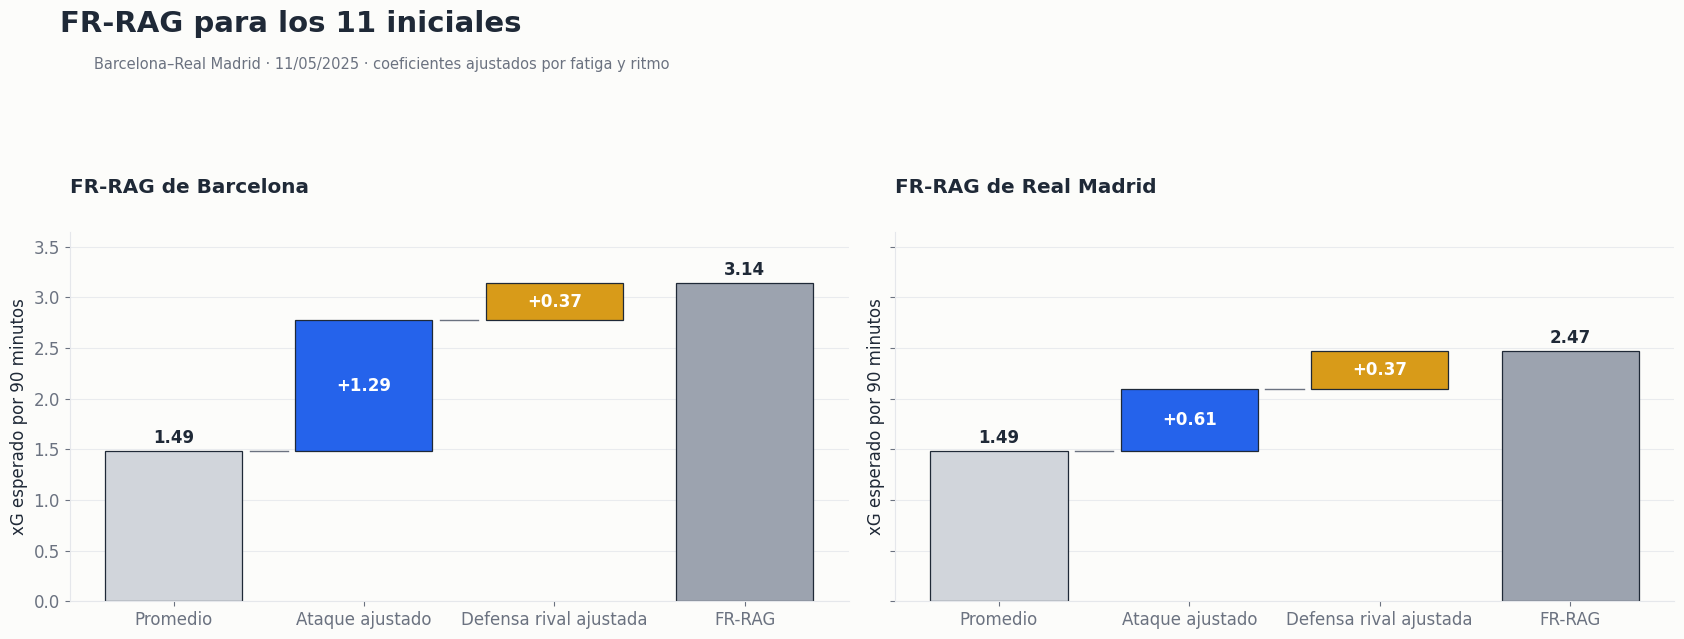

,Fatiga media,Ritmo medio,FR-RAG por 90
Equipo,,,
Barcelona,0.276,0.961,3.143
Real Madrid,0.106,0.631,2.472


In [7]:
def draw_waterfall(ax, baseline, attack, defense, result, title):
    labels = ["Promedio", "Ataque ajustado", "Defensa rival ajustada", "FR-RAG"]
    starts = [0, baseline, baseline + attack, 0]
    values = [baseline, attack, defense, result]
    colors = ["#D1D5DB", BLUE, GOLD, "#9CA3AF"]
    for index, (start, value, color) in enumerate(zip(starts, values, colors)):
        bottom = start if value >= 0 else start + value
        height = abs(value)
        ax.bar(index, height, bottom=bottom, color=color, edgecolor=INK, linewidth=0.9, width=0.72)
        label_y = bottom + height / 2 if index in (1, 2) else bottom + height + 0.04
        label_color = "white" if index in (1, 2) else INK
        va = "center" if index in (1, 2) else "bottom"
        ax.text(index, label_y, f"{value:+.2f}" if index in (1, 2) else f"{value:.2f}",
                ha="center", va=va, color=label_color, fontweight="bold", fontsize=12)
        if index < 2:
            ax.plot([index + 0.4, index + 0.6], [start + value, start + value], color=MUTED, linewidth=1)
    ax.set_xticks(range(4), labels)
    ax.set_title(title, loc="left", pad=28)
    ax.set_ylabel("xG esperado por 90 minutos")
    clean_axes(ax)

def fr_rag_for_lineup(own_lineup, opponent_lineup):
    attack = lineup_state.loc[own_lineup, "fr_off_90"].sum()
    opponent_defense = -lineup_state.loc[opponent_lineup, "fr_def_90"].sum()
    return baseline_90 + attack + opponent_defense, attack, opponent_defense

barcelona_fr, barcelona_attack, madrid_defense = fr_rag_for_lineup(barcelona_xi, madrid_xi)
madrid_fr, madrid_attack, barcelona_defense = fr_rag_for_lineup(madrid_xi, barcelona_xi)
assert np.isclose(baseline_90 + barcelona_attack + madrid_defense, barcelona_fr)
assert np.isclose(baseline_90 + madrid_attack + barcelona_defense, madrid_fr)
assert len(lineup_state) == 22

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), sharey=True)
draw_waterfall(axes[0], baseline_90, barcelona_attack, madrid_defense,
               barcelona_fr, "FR-RAG de Barcelona")
draw_waterfall(axes[1], baseline_90, madrid_attack, barcelona_defense,
               madrid_fr, "FR-RAG de Real Madrid")
upper = max(barcelona_fr, madrid_fr, baseline_90 + barcelona_attack, baseline_90 + madrid_attack) * 1.16
for ax in axes:
    ax.set_ylim(0, upper)
fig.suptitle("FR-RAG para los 11 iniciales", x=0.04, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "Barcelona–Real Madrid · 11/05/2025 · coeficientes ajustados por fatiga y ritmo", subtitle_y=0.89)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

display(pd.DataFrame({
    "Equipo": ["Barcelona", "Real Madrid"],
    "Fatiga media": [lineup_state.loc[barcelona_xi, "fatigue"].mean(), lineup_state.loc[madrid_xi, "fatigue"].mean()],
    "Ritmo medio": [lineup_state.loc[barcelona_xi, "rhythm"].mean(), lineup_state.loc[madrid_xi, "rhythm"].mean()],
    "FR-RAG por 90": [barcelona_fr, madrid_fr],
}).set_index("Equipo").round(3))
# Shared example inputs: retain raw quality, update only fatigue/rhythm curves.
snapshots = pd.read_csv(DATA_DIR / "substitutions_barca_real_madrid.csv", encoding="utf-8-sig")
snapshots = snapshots[snapshots["match_id"] == CLASICO_ID].set_index("player_id")
strength = raw_ratings.reindex(snapshots.index).fillna(0.0).rename(columns={"off_90": "off_raw_90", "def_90": "def_raw_90"}).join(snapshots[["fatigue", "rhythm"]])
strength[["fatigue", "rhythm"]] = strength[["fatigue", "rhythm"]].fillna(0.0)
strength.loc[lineup_state.index, ["fatigue", "rhythm"]] = lineup_state[["fatigue", "rhythm"]]
assert strength[["fatigue", "rhythm", "off_raw_90", "def_raw_90"]].notna().all().all()
strength["off_90"] = strength["off_raw_90"] + predict_adjustment(rhythm_model, rhythm_design, "rhythm", strength["rhythm"]) * 90
strength["def_90"] = strength["def_raw_90"] + predict_adjustment(fatigue_model, fatigue_design, "fatigue", strength["fatigue"]) * 90
updated_segments = []
for _, row in clasico.iterrows():
    a, b = row["teamA_players"], row["teamB_players"]
    updated_segments.append({"segment_id": row["segment_id"], "home_fr_rag90": baseline_90 + strength.loc[a, "off_90"].sum() - strength.loc[b, "def_90"].sum(), "away_fr_rag90": baseline_90 + strength.loc[b, "off_90"].sum() - strength.loc[a, "def_90"].sum()})
updated_segments = pd.DataFrame(updated_segments)
np.testing.assert_allclose(updated_segments.iloc[0][["home_fr_rag90", "away_fr_rag90"]].to_numpy(dtype=float), [barcelona_fr, madrid_fr])
# Actualizar los datos del ejemplo en los archivos existentes.
segment_export = pd.read_csv(DATA_DIR / "clasico_contextual_segments.csv")
segment_rates = updated_segments.set_index("segment_id")
for side, column in [("home", "teamA_fr_rag"), ("away", "teamB_fr_rag")]:
    rates = segment_export["segment_id"].map(segment_rates[f"{side}_fr_rag90"])
    assert rates.notna().all()
    segment_export[column] = rates * segment_export["minutes_played"] / 90
segment_export.to_csv(DATA_DIR / "clasico_contextual_segments.csv", index=False)
snapshot_export = pd.read_csv(DATA_DIR / "substitutions_barca_real_madrid.csv", encoding="utf-8-sig")
mask = snapshot_export["match_id"].eq(CLASICO_ID)
for column, source_column, scale in [("off_xg_coef", "off_raw_90", 90), ("def_xg_coef", "def_raw_90", 90), ("fatigue", "fatigue", 1), ("rhythm", "rhythm", 1)]:
    values = snapshot_export.loc[mask, "player_id"].map(strength[source_column]) / scale
    assert values.notna().all()
    snapshot_export.loc[mask, column] = values
snapshot_export.to_csv(DATA_DIR / "substitutions_barca_real_madrid.csv", index=False, encoding="utf-8-sig")


## Qué nos llevamos

- Raw RAG aporta la calidad base; Fatigue & Rhythm RAG añade el estado con el que cada jugador llega al partido.
- La fatiga responde sobre todo a los últimos días. El ritmo conserva una ventana más larga de continuidad.
- Los splines permiten que el ajuste cambie a lo largo del rango sin imponer una línea recta.
- El FR-RAG mantiene una estructura interpretable: promedio de liga, ataque ajustado propio y defensa ajustada del rival.

Esta segunda capa convierte una valoración relativamente estable en una estimación sensible al calendario reciente de cada alineación.

## Checks de reproducibilidad

- Fuente del entrenamiento: `02_data/player_fatigue_rhythm.csv`, exportado de VSP con contexto de partido y liga.
- Fuente de alineaciones y Raw RAG: `02_data/raw_rag_la_liga.csv`.
- Muestra reproducible de minutos: `02_data/featured_player_match_history.csv`, limitada al historial previo de los 22 titulares del Clásico; la sección 1 visualiza a Lamine Yamal y Kylian Mbappé.
- Fatiga: decay exponencial de 3 días, normalización por 90 y límite de 1.
- Ritmo: decay exponencial de 7 días, normalización por 90 y límite de 1.
- Ajustes: splines cuadráticos con 3 grados de libertad y `Ridge(alpha=1e-5)`.
- Caso final: `match_id=28055`, 19 segmentos, 98 minutos y 22 titulares.
- El notebook no abre conexiones SQL ni necesita `vsp.sql` para ejecutarse.